In [242]:
import pandas as pd
import numpy as np

In [243]:
df = pd.read_csv('global_cancer_patients_2015_2024.csv')
df

,Patient_ID,Age,Gender,Country_Region,Year,Genetic_Risk,Air_Pollution,Alcohol_Use,Smoking,Obesity_Level,Cancer_Type,Cancer_Stage,Treatment_Cost_USD,Survival_Years,Target_Severity_Score
0,PT0000000,71,Male,UK,2021,6.4,2.8,9.5,0.9,8.7,Lung,Stage III,62913.44,5.9,4.92
1,PT0000001,34,Male,China,2021,1.3,4.5,3.7,3.9,6.3,Leukemia,Stage 0,12573.41,4.7,4.65
2,PT0000002,80,Male,Pakistan,2023,7.4,7.9,2.4,4.7,0.1,Breast,Stage II,6984.33,7.1,5.84
3,PT0000003,40,Male,UK,2015,1.7,2.9,4.8,3.5,2.7,Colon,Stage I,67446.25,1.6,3.12
4,PT0000004,43,Female,Brazil,2017,5.1,2.8,2.3,6.7,0.5,Skin,Stage III,77977.12,2.9,3.62
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,PT0049995,80,Male,Pakistan,2023,2.3,7.5,2.8,3.8,2.9,Leukemia,Stage 0,71463.70,1.0,3.63
49996,PT0049996,40,Female,USA,2018,6.4,3.5,2.9,9.0,9.8,Colon,Stage I,49619.66,0.4,6.03
49997,PT0049997,74,Male,Pakistan,2015,6.2,1.6,8.7,4.7,4.0,Breast,Stage 0,5338.25,2.7,6.02
49998,PT0049998,21,Male,Brazil,2018,4.0,6.5,7.6,8.6,8.1,Liver,Stage IV,45100.47,7.5,6.54


In [244]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Patient_ID             50000 non-null  object 
 1   Age                    50000 non-null  int64  
 2   Gender                 50000 non-null  object 
 3   Country_Region         50000 non-null  object 
 4   Year                   50000 non-null  int64  
 5   Genetic_Risk           50000 non-null  float64
 6   Air_Pollution          50000 non-null  float64
 7   Alcohol_Use            50000 non-null  float64
 8   Smoking                50000 non-null  float64
 9   Obesity_Level          50000 non-null  float64
 10  Cancer_Type            50000 non-null  object 
 11  Cancer_Stage           50000 non-null  object 
 12  Treatment_Cost_USD     50000 non-null  float64
 13  Survival_Years         50000 non-null  float64
 14  Target_Severity_Score  50000 non-null  float64
dtypes:

In [245]:
df.head()

,Patient_ID,Age,Gender,Country_Region,Year,Genetic_Risk,Air_Pollution,Alcohol_Use,Smoking,Obesity_Level,Cancer_Type,Cancer_Stage,Treatment_Cost_USD,Survival_Years,Target_Severity_Score
0,PT0000000,71,Male,UK,2021,6.4,2.8,9.5,0.9,8.7,Lung,Stage III,62913.44,5.9,4.92
1,PT0000001,34,Male,China,2021,1.3,4.5,3.7,3.9,6.3,Leukemia,Stage 0,12573.41,4.7,4.65
2,PT0000002,80,Male,Pakistan,2023,7.4,7.9,2.4,4.7,0.1,Breast,Stage II,6984.33,7.1,5.84
3,PT0000003,40,Male,UK,2015,1.7,2.9,4.8,3.5,2.7,Colon,Stage I,67446.25,1.6,3.12
4,PT0000004,43,Female,Brazil,2017,5.1,2.8,2.3,6.7,0.5,Skin,Stage III,77977.12,2.9,3.62


In [246]:
df.describe()

,Age,Year,Genetic_Risk,Air_Pollution,Alcohol_Use,Smoking,Obesity_Level,Treatment_Cost_USD,Survival_Years,Target_Severity_Score
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,54.421540,2019.480520,5.001698,5.010126,5.010880,4.989826,4.991176,52467.298239,5.006462,4.951207
std,20.224451,2.871485,2.885773,2.888399,2.888769,2.881579,2.894504,27363.229379,2.883335,1.199677
min,20.000000,2015.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5000.050000,0.000000,0.900000
25%,37.000000,2017.000000,2.500000,2.500000,2.500000,2.500000,2.500000,28686.225000,2.500000,4.120000
50%,54.000000,2019.000000,5.000000,5.000000,5.000000,5.000000,5.000000,52474.310000,5.000000,4.950000
75%,72.000000,2022.000000,7.500000,7.500000,7.500000,7.500000,7.500000,76232.720000,7.500000,5.780000
max,89.000000,2024.000000,10.000000,10.000000,10.000000,10.000000,10.000000,99999.840000,10.000000,9.160000


In [247]:
df.isnull().sum()

Patient_ID               0
Age                      0
Gender                   0
Country_Region           0
Year                     0
Genetic_Risk             0
Air_Pollution            0
Alcohol_Use              0
Smoking                  0
Obesity_Level            0
Cancer_Type              0
Cancer_Stage             0
Treatment_Cost_USD       0
Survival_Years           0
Target_Severity_Score    0
dtype: int64

In [248]:
df_cleaned = df.dropna()

In [249]:
df_cleaned.duplicated().sum()

0

In [250]:
Q1 = df_cleaned['Age'].quantile(0.25)
Q3 = df_cleaned['Age'].quantile(0.75)
IQR = Q3 - Q1

In [251]:
df_cleaned = df_cleaned[(df_cleaned['Age'] >= Q1 - 1.5 * IQR) & (df_cleaned['Age'] <= Q3 + 1.5 * IQR)]

In [252]:
df_cleaned.select_dtypes(include='object').columns

Index(['Patient_ID', 'Gender', 'Country_Region', 'Cancer_Type',
       'Cancer_Stage'],
      dtype='object')

In [253]:
df_encoded = pd.get_dummies(df_cleaned, drop_first=True)

In [254]:
from sklearn.preprocessing import StandardScaler

In [255]:
numerical_cols = df_encoded.select_dtypes(include=['int64', 'float64']).columns

In [256]:
scaler = StandardScaler()
df_encoded[numerical_cols] = scaler.fit_transform(df_encoded[numerical_cols])

In [257]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [258]:
features = [
    'Age', 'Gender', 'Country_Region', 'Year', 'Genetic_Risk', 'Air_Pollution',
    'Alcohol_Use', 'Smoking', 'Obesity_Level', 'Cancer_Type', 'Cancer_Stage'
]
target = 'Survival_Years'

X = df[features]
y = df[target]

In [259]:
numerical_features = ['Age', 'Year', 'Genetic_Risk', 'Air_Pollution', 'Alcohol_Use', 'Smoking', 'Obesity_Level']
categorical_features = ['Gender', 'Country_Region', 'Cancer_Type', 'Cancer_Stage']

In [260]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

In [261]:
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

In [262]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [263]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Age', 'Year',
                                                   'Genetic_Risk',
                                                   'Air_Pollution',
                                                   'Alcohol_Use', 'Smoking',
                                                   'Obesity_Level']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Gender', 'Country_Region',
                                                   'Cancer_Type',
                                                   'Cancer_Stage'])])),
                ('regressor', LinearRegression())])

In [264]:
y_pred = pipeline.predict(X_test)

In [265]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

mse, r2

(8.325941203174233, -0.0005506344789809603)

In [266]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, learning_curve, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

In [267]:
df = pd.read_csv("global_cancer_patients_2015_2024.csv")

In [268]:
features = [
    'Age', 'Gender', 'Country_Region', 'Year', 'Genetic_Risk', 'Air_Pollution',
    'Alcohol_Use', 'Smoking', 'Obesity_Level', 'Cancer_Type', 'Cancer_Stage'
]
target = 'Survival_Years'
X = df[features]
y = df[target]

In [269]:
numerical = ['Age', 'Year', 'Genetic_Risk', 'Air_Pollution', 'Alcohol_Use', 'Smoking', 'Obesity_Level']
categorical = ['Gender', 'Country_Region', 'Cancer_Type', 'Cancer_Stage']
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numerical),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical)
])

In [270]:
ridge = Pipeline([('preprocessor', preprocessor), ('regressor', Ridge(alpha=1.0))])
lasso = Pipeline([('preprocessor', preprocessor), ('regressor', Lasso(alpha=0.1))])

In [271]:
def plot_learning_curve(model, title):
    train_sizes, train_scores, test_scores = learning_curve(
        model, X, y, cv=3, scoring='r2', train_sizes=np.linspace(0.1, 1.0, 5), n_jobs=-1)
    plt.figure()
    plt.plot(train_sizes, np.mean(train_scores, axis=1), 'o-', label='Train R²')
    plt.plot(train_sizes, np.mean(test_scores, axis=1), 'o-', label='Test R²')
    plt.title(title)
    plt.xlabel('Training Set Size')
    plt.ylabel('R² Score')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

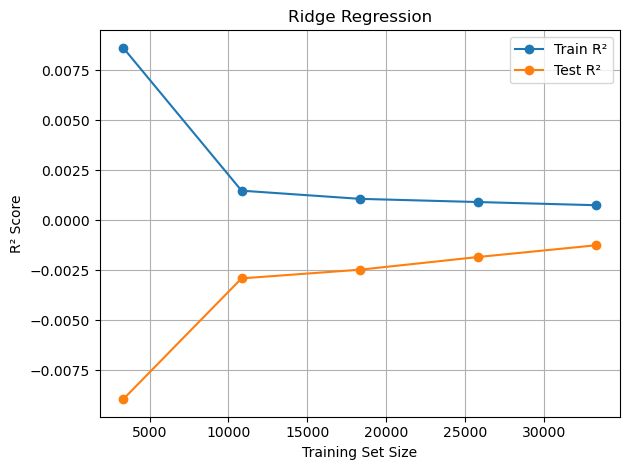

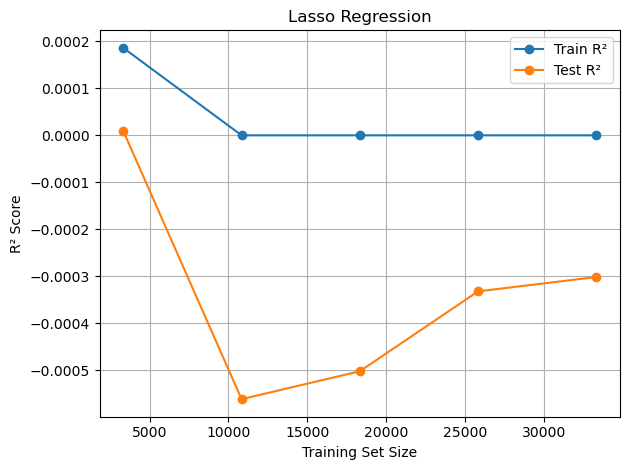

In [272]:
plot_learning_curve(ridge, "Ridge Regression")
plot_learning_curve(lasso, "Lasso Regression")

In [273]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error

In [274]:
df_model = df.drop(columns=["Patient_ID", "Cancer_Type", "Cancer_Stage", "Country_Region", "Gender"])
df_model = df_model.dropna()
X = df_model.drop(columns=["Target_Severity_Score"])
y = df_model["Target_Severity_Score"]

In [275]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [276]:
ridge_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge())
])
ridge_params = {'ridge__alpha': [0.01, 0.1, 1, 10, 100]}
ridge_grid = GridSearchCV(ridge_pipeline, ridge_params, cv=5, scoring='r2')
ridge_grid.fit(X_train, y_train)


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('ridge', Ridge())]),
             param_grid={'ridge__alpha': [0.01, 0.1, 1, 10, 100]},
             scoring='r2')

In [277]:
ridge_best = ridge_grid.best_estimator_
y_pred = ridge_best.predict(X_test)
print("Best Alpha:", ridge_grid.best_params_['ridge__alpha'])
print("R2 Score:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

Best Alpha: 0.01
R2 Score: 0.9999941382435791
MSE: 8.328778982036173e-06


In [278]:
from sklearn.linear_model import Lasso

In [279]:
lasso_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', Lasso(max_iter=10000))
])
lasso_params = {'lasso__alpha': [0.01, 0.1, 1, 10, 100]}
lasso_grid = GridSearchCV(lasso_pipeline, lasso_params, cv=5, scoring='r2')
lasso_grid.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('lasso', Lasso(max_iter=10000))]),
             param_grid={'lasso__alpha': [0.01, 0.1, 1, 10, 100]},
             scoring='r2')

In [280]:
lasso_best = lasso_grid.best_estimator_
lasso_pred = lasso_best.predict(X_test)

print("Best Alpha (Lasso):", lasso_grid.best_params_['lasso__alpha'])
print("R2 Score (Lasso):", r2_score(y_test, lasso_pred))
print("MSE (Lasso):", mean_squared_error(y_test, lasso_pred))

Best Alpha (Lasso): 0.01
R2 Score (Lasso): 0.9995844692345484
MSE (Lasso): 0.0005904141450372586


In [281]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [282]:
df = pd.read_csv("global_cancer_patients_2015_2024.csv")

In [283]:
numeric_df = df.select_dtypes(include=["int64", "float64"])

In [284]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(numeric_df)

In [285]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(scaled_data)

In [286]:
pca = PCA(n_components=2)
pca_components = pca.fit_transform(scaled_data)
df['PCA1'] = pca_components[:, 0]
df['PCA2'] = pca_components[:, 1]

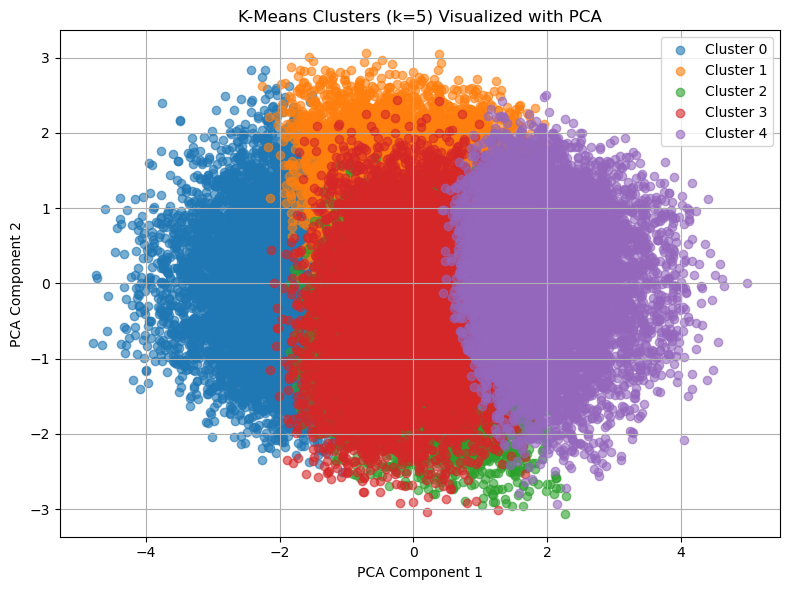

In [287]:
plt.figure(figsize=(8, 6))
for cluster in sorted(df['Cluster'].unique()):
    cluster_data = df[df['Cluster'] == cluster]
    plt.scatter(cluster_data['PCA1'], cluster_data['PCA2'], label=f'Cluster {cluster}', alpha=0.6)
plt.title('K-Means Clusters (k=5) Visualized with PCA')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [288]:
cluster_summary = df.groupby('Cluster')[numeric_df.columns].mean().round(2)
display(cluster_summary)

,Age,Year,Genetic_Risk,Air_Pollution,Alcohol_Use,Smoking,Obesity_Level,Treatment_Cost_USD,Survival_Years,Target_Severity_Score
Cluster,,,,,,,,,,
0,54.38,2019.49,2.85,3.80,3.84,2.89,4.19,70542.47,4.94,3.30
1,54.53,2019.56,7.52,4.95,5.03,2.40,4.86,52636.20,5.03,4.92
2,54.35,2019.38,2.43,5.18,5.15,5.19,4.98,28182.53,4.88,5.01
3,54.28,2019.42,4.98,4.98,4.91,7.52,5.07,76806.25,5.16,4.95
4,54.57,2019.57,7.17,6.16,6.15,7.02,5.87,33369.11,5.01,6.61


In [289]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder

In [290]:
df_model = df.drop(columns=['Patient_ID', 'Target_Severity_Score'])

In [291]:
categorical_cols = ['Gender', 'Country_Region', 'Cancer_Type', 'Cancer_Stage']
df_model[categorical_cols] = df_model[categorical_cols].apply(LabelEncoder().fit_transform)

In [292]:
def categorize_severity(score):
    if score < 3.5:
        return 0  
    elif score < 5.0:
        return 1  
    else:
        return 2 

df['Severity_Class'] = df['Target_Severity_Score'].apply(categorize_severity)

In [293]:
from sklearn.preprocessing import LabelEncoder

df_model = df.drop(columns=['Patient_ID', 'Target_Severity_Score'])

categorical_cols = ['Gender', 'Country_Region', 'Cancer_Type', 'Cancer_Stage']
df_model[categorical_cols] = df_model[categorical_cols].apply(LabelEncoder().fit_transform)

X = df_model.drop(columns=['Severity_Class'])
y = df_model['Severity_Class']

In [294]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [295]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [296]:
y_pred = rf_model.predict(X_test)
report = classification_report(y_test, y_pred, output_dict=True)

In [297]:
import pandas as pd
from sklearn.metrics import classification_report

report = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report).transpose()

report_df

,precision,recall,f1-score,support
0,0.997396,0.993086,0.995236,1157.0000
1,0.994801,0.997022,0.995910,4030.0000
2,0.998129,0.997299,0.997714,4813.0000
accuracy,0.996700,0.996700,0.996700,0.9967
macro avg,0.996775,0.995802,0.996287,10000.0000
weighted avg,0.996703,0.996700,0.996700,10000.0000


In [298]:
from sklearn.metrics import accuracy_score

In [299]:
y_train_pred = rf_model.predict(X_train)
y_test_pred = rf_model.predict(X_test)

In [300]:
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

In [301]:
print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Test Accuracy:     {test_accuracy:.4f}")

Training Accuracy: 1.0000
Test Accuracy:     0.9967


In [302]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve

In [303]:
train_sizes, train_scores, test_scores = learning_curve(
    rf_model, X, y, cv=5, scoring='accuracy', train_sizes=np.linspace(0.1, 1.0, 5), random_state=42
)

In [304]:
train_scores_mean = np.mean(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)

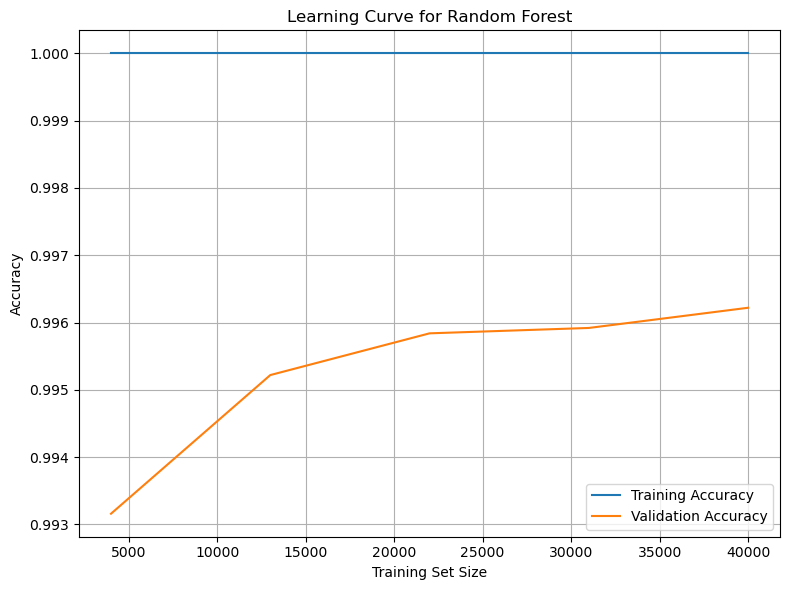

In [305]:
plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_scores_mean, label='Training Accuracy')
plt.plot(train_sizes, test_scores_mean, label='Validation Accuracy')
plt.title('Learning Curve for Random Forest')
plt.xlabel('Training Set Size')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [306]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

In [307]:
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

In [308]:
rf_base = RandomForestClassifier(random_state=42)

In [309]:
grid_search = GridSearchCV(estimator=rf_base,
                           param_grid=param_grid,
                           cv=5,
                           scoring='accuracy',
                           n_jobs=-1,
                           verbose=1)

In [310]:
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [10, 20, None],
                         'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [50, 100]},
             scoring='accuracy', verbose=1)

In [311]:
best_rf = grid_search.best_estimator_

In [312]:
print("Best Parameters:", grid_search.best_params_)
print("Best CV Accuracy:", grid_search.best_score_)

Best Parameters: {'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}
Best CV Accuracy: 0.9958750000000001


In [313]:
from sklearn.metrics import classification_report

In [314]:
y_best_pred = best_rf.predict(X_test)

In [315]:
print(classification_report(y_test, y_best_pred))

              precision    recall  f1-score   support

           0       1.00      0.99      0.99      1157
           1       0.99      1.00      1.00      4030
           2       1.00      1.00      1.00      4813

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000



In [316]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [317]:
y_pred = best_rf.predict(X_test)

In [318]:
cm = confusion_matrix(y_test, y_pred)

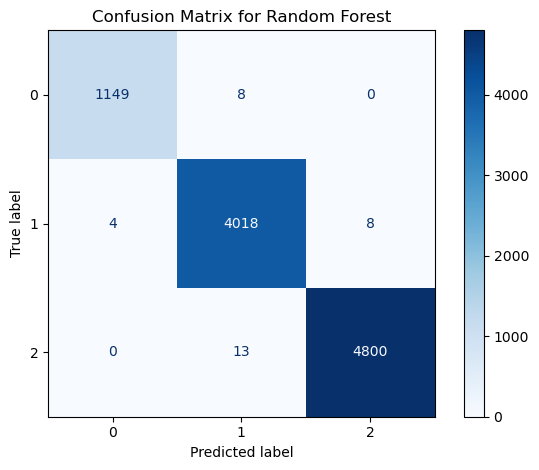

In [319]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_rf.classes_)
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix for Random Forest')
plt.grid(False)
plt.tight_layout()
plt.show()

In [320]:
import streamlit as st
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score, classification_report, accuracy_score, silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

In [321]:
st.set_page_config(page_title="ML Cancer App", layout="wide")

In [322]:
@st.cache_data
def load_data():
    return pd.read_csv("global_cancer_patients_2015_2024.csv")

2025-05-01 15:34:42.570 No runtime found, using MemoryCacheStorageManager


In [323]:
def plot_learning_curve(model, X, y, title):
    train_sizes, train_scores, test_scores = learning_curve(
        model, X, y, cv=5, scoring='r2', train_sizes=np.linspace(0.1, 1.0, 5), n_jobs=-1
    )
    plt.figure()
    plt.plot(train_sizes, np.mean(train_scores, axis=1), label="Train")
    plt.plot(train_sizes, np.mean(test_scores, axis=1), label="Test")
    plt.title(title)
    plt.xlabel("Training size")
    plt.ylabel("R² Score")
    plt.legend()
    st.pyplot(plt.gcf())

In [324]:
df = load_data()
st.title("Cancer ML Web Application")

DeltaGenerator()

In [325]:
model_type = st.sidebar.selectbox("Choose model type", ["Regression", "Clustering", "Classification"])

In [326]:
if model_type == "Regression":
  
    features = ['Age', 'Gender', 'Country_Region', 'Year', 'Genetic_Risk', 'Air_Pollution',
                'Alcohol_Use', 'Smoking', 'Obesity_Level', 'Cancer_Type', 'Cancer_Stage']
    target = 'Survival_Years'
    X = df[features]
    y = df[target]

In [327]:
    num_cols = ['Age', 'Year', 'Genetic_Risk', 'Air_Pollution', 'Alcohol_Use', 'Smoking', 'Obesity_Level']
    cat_cols = ['Gender', 'Country_Region', 'Cancer_Type', 'Cancer_Stage']

    preprocessor = ColumnTransformer([
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ])

In [328]:
model_name = "Ridge"

In [329]:
alpha = 1.0 

In [330]:
if model_name == "LinearRegression":
    model = LinearRegression()
elif model_name == "Ridge":
    model = Ridge(alpha=alpha)
else:
    model = Lasso(alpha=alpha)

In [331]:
pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', model)
    ])

In [332]:
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve
import numpy as np

In [333]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Age', 'Year',
                                                   'Genetic_Risk',
                                                   'Air_Pollution',
                                                   'Alcohol_Use', 'Smoking',
                                                   'Obesity_Level']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Gender', 'Country_Region',
                                                   'Cancer_Type',
                                                   'Cancer_Stage'])])),
                ('regressor', Ridge())])

In [334]:
y_pred = pipeline.predict(X_test)
print("MSE:", mean_squared_error(y_test, y_pred))
print("R² Score:", r2_score(y_test, y_pred))

MSE: 8.32397662298117
R² Score: -0.0003145456199935559


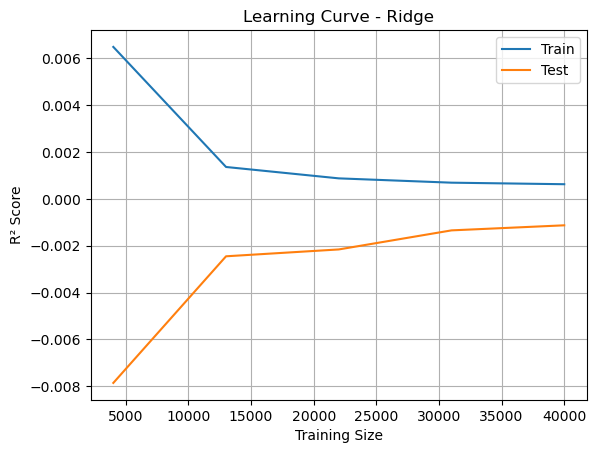

In [335]:
train_sizes, train_scores, test_scores = learning_curve(
    pipeline, X, y, cv=5, scoring='r2', train_sizes=np.linspace(0.1, 1.0, 5), n_jobs=-1
)

plt.plot(train_sizes, np.mean(train_scores, axis=1), label="Train")
plt.plot(train_sizes, np.mean(test_scores, axis=1), label="Test")
plt.title(f"Learning Curve - {model_name}")
plt.xlabel("Training Size")
plt.ylabel("R² Score")
plt.legend()
plt.grid(True)
plt.show()

In [336]:
from sklearn.preprocessing import StandardScaler

numeric_df = df.select_dtypes(include=["float64", "int64"])
scaled = StandardScaler().fit_transform(numeric_df.drop(columns=["Year"]))

In [337]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

k = 5  

model = KMeans(n_clusters=k, random_state=42, n_init=10)
df['Cluster'] = model.fit_predict(scaled)

score = silhouette_score(scaled, df['Cluster'])
print("Silhouette Score:", score)

Silhouette Score: 0.09152044011430902


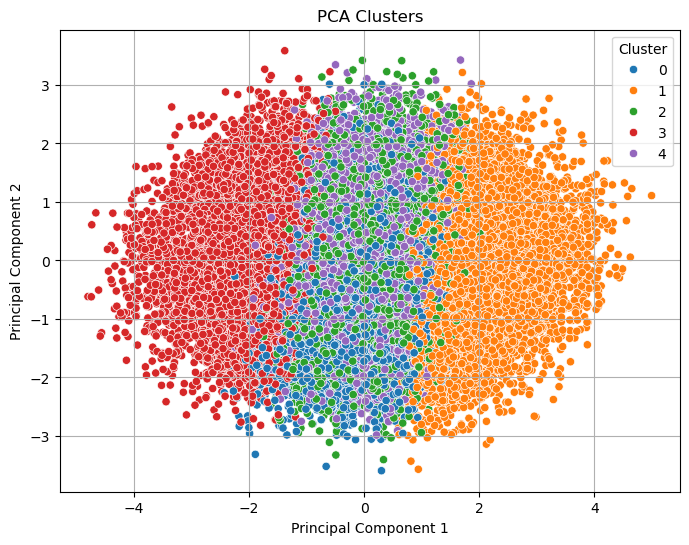

In [338]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled)
df['PCA1'] = pca_data[:, 0]
df['PCA2'] = pca_data[:, 1]

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='PCA1', y='PCA2', hue='Cluster', palette='tab10')
plt.title("PCA Clusters")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)
plt.show()

In [339]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score
import pandas as pd

In [340]:
df['Severity_Class'] = df['Target_Severity_Score'].apply(lambda x: 0 if x < 3.5 else (1 if x < 5 else 2))

In [341]:
df_model = df.drop(columns=["Patient_ID", "Target_Severity_Score"])

In [342]:
cat_cols = ['Gender', 'Country_Region', 'Cancer_Type', 'Cancer_Stage']
for col in cat_cols:
    df_model[col] = LabelEncoder().fit_transform(df_model[col])

In [343]:
X = df_model.drop(columns=["Severity_Class"])
y = df_model["Severity_Class"]

In [344]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [345]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

In [346]:
print("Accuracy:", accuracy_score(y_test, y_pred))
report_df = pd.DataFrame(classification_report(y_test, y_pred, output_dict=True)).transpose()
display(report_df)

Accuracy: 0.9964


,precision,recall,f1-score,support
0,0.997391,0.991357,0.994365,1157.0000
1,0.994552,0.996526,0.995538,4030.0000
2,0.997714,0.997507,0.997610,4813.0000
accuracy,0.996400,0.996400,0.996400,0.9964
macro avg,0.996552,0.995130,0.995838,10000.0000
weighted avg,0.996402,0.996400,0.996400,10000.0000
